### 유방암 세포 진단

In [ ]:
import sys
print('Python: {}'.format(sys.version))
!{sys.executable} -m pip install scipy matplotlib pandas scikit-learn

Python: 3.9.25 (main, Nov  3 2025, 22:29:32) 
[Clang 20.1.8 ]


In [8]:
import scipy
import numpy
import matplotlib
import pandas
import sklearn

In [10]:
pkgs = [scipy, numpy, matplotlib, pandas, sklearn]
for pkg in pkgs:
    print('{}: {}'.format(pkg.__name__, pkg.__version__))

scipy: 1.13.1
numpy: 2.0.2
matplotlib: 3.9.4
pandas: 2.3.3
sklearn: 1.6.1


In [12]:
import numpy as np
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


In [14]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
names=['id', 'clump_thickness', 'uniform_cell_size', 'uniform_cell_shape', 'marginal_adhesion', 'single_epithelial_cell_size', 'bare_nuclei', 'bland_chromatin', 'normal_nucleoli', 'mitosis', 'class']
df = pd.read_csv(url, names=names)

In [16]:
df.replace('?', -99999, inplace=True)
print(df.axes)

[RangeIndex(start=0, stop=699, step=1), Index(['id', 'clump_thickness', 'uniform_cell_size', 'uniform_cell_shape',
       'marginal_adhesion', 'single_epithelial_cell_size', 'bare_nuclei',
       'bland_chromatin', 'normal_nucleoli', 'mitosis', 'class'],
      dtype='object')]


In [19]:
df.drop(columns="id", axis=1, inplace=True)

In [20]:
print(df.loc[10])

clump_thickness                1
uniform_cell_size              1
uniform_cell_shape             1
marginal_adhesion              1
single_epithelial_cell_size    1
bare_nuclei                    1
bland_chromatin                3
normal_nucleoli                1
mitosis                        1
class                          2
Name: 10, dtype: object


In [24]:
print(df.shape)

(699, 10)


In [25]:
print(df.describe())

       clump_thickness  uniform_cell_size  uniform_cell_shape  \
count       699.000000         699.000000          699.000000   
mean          4.417740           3.134478            3.207439   
std           2.815741           3.051459            2.971913   
min           1.000000           1.000000            1.000000   
25%           2.000000           1.000000            1.000000   
50%           4.000000           1.000000            1.000000   
75%           6.000000           5.000000            5.000000   
max          10.000000          10.000000           10.000000   

       marginal_adhesion  single_epithelial_cell_size  bland_chromatin  \
count         699.000000                   699.000000       699.000000   
mean            2.806867                     3.216023         3.437768   
std             2.855379                     2.214300         2.438364   
min             1.000000                     1.000000         1.000000   
25%             1.000000                    

In [26]:
print(df.head(20))

    clump_thickness  uniform_cell_size  uniform_cell_shape  marginal_adhesion  \
0                 5                  1                   1                  1   
1                 5                  4                   4                  5   
2                 3                  1                   1                  1   
3                 6                  8                   8                  1   
4                 4                  1                   1                  3   
5                 8                 10                  10                  8   
6                 1                  1                   1                  1   
7                 2                  1                   2                  1   
8                 2                  1                   1                  1   
9                 4                  2                   1                  1   
10                1                  1                   1                  1   
11                2         

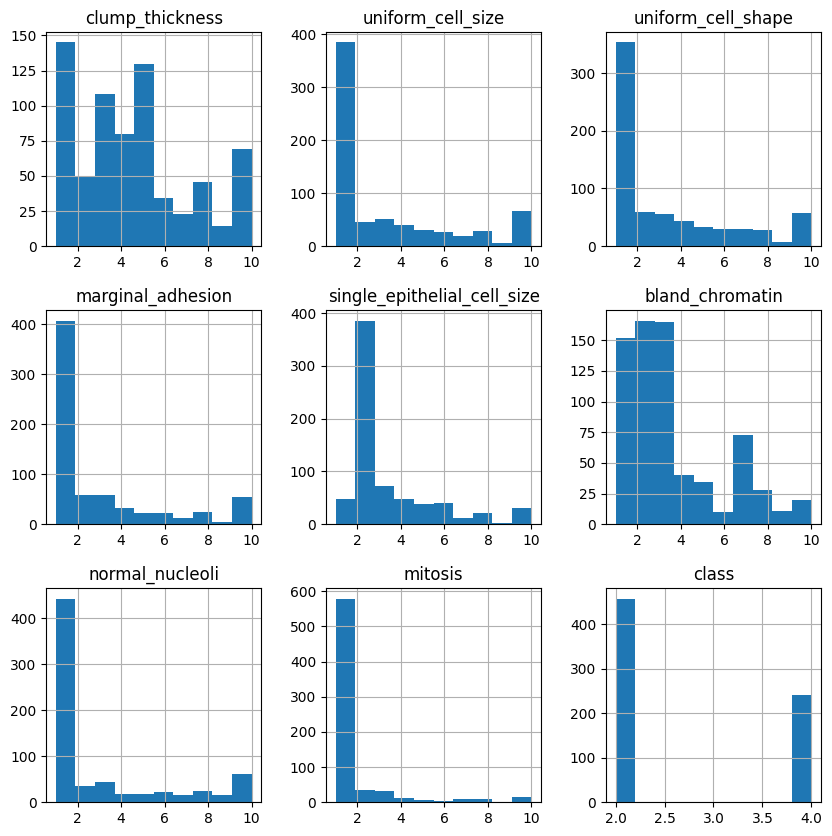

In [27]:
df.hist(figsize = (10, 10))
plt.show()

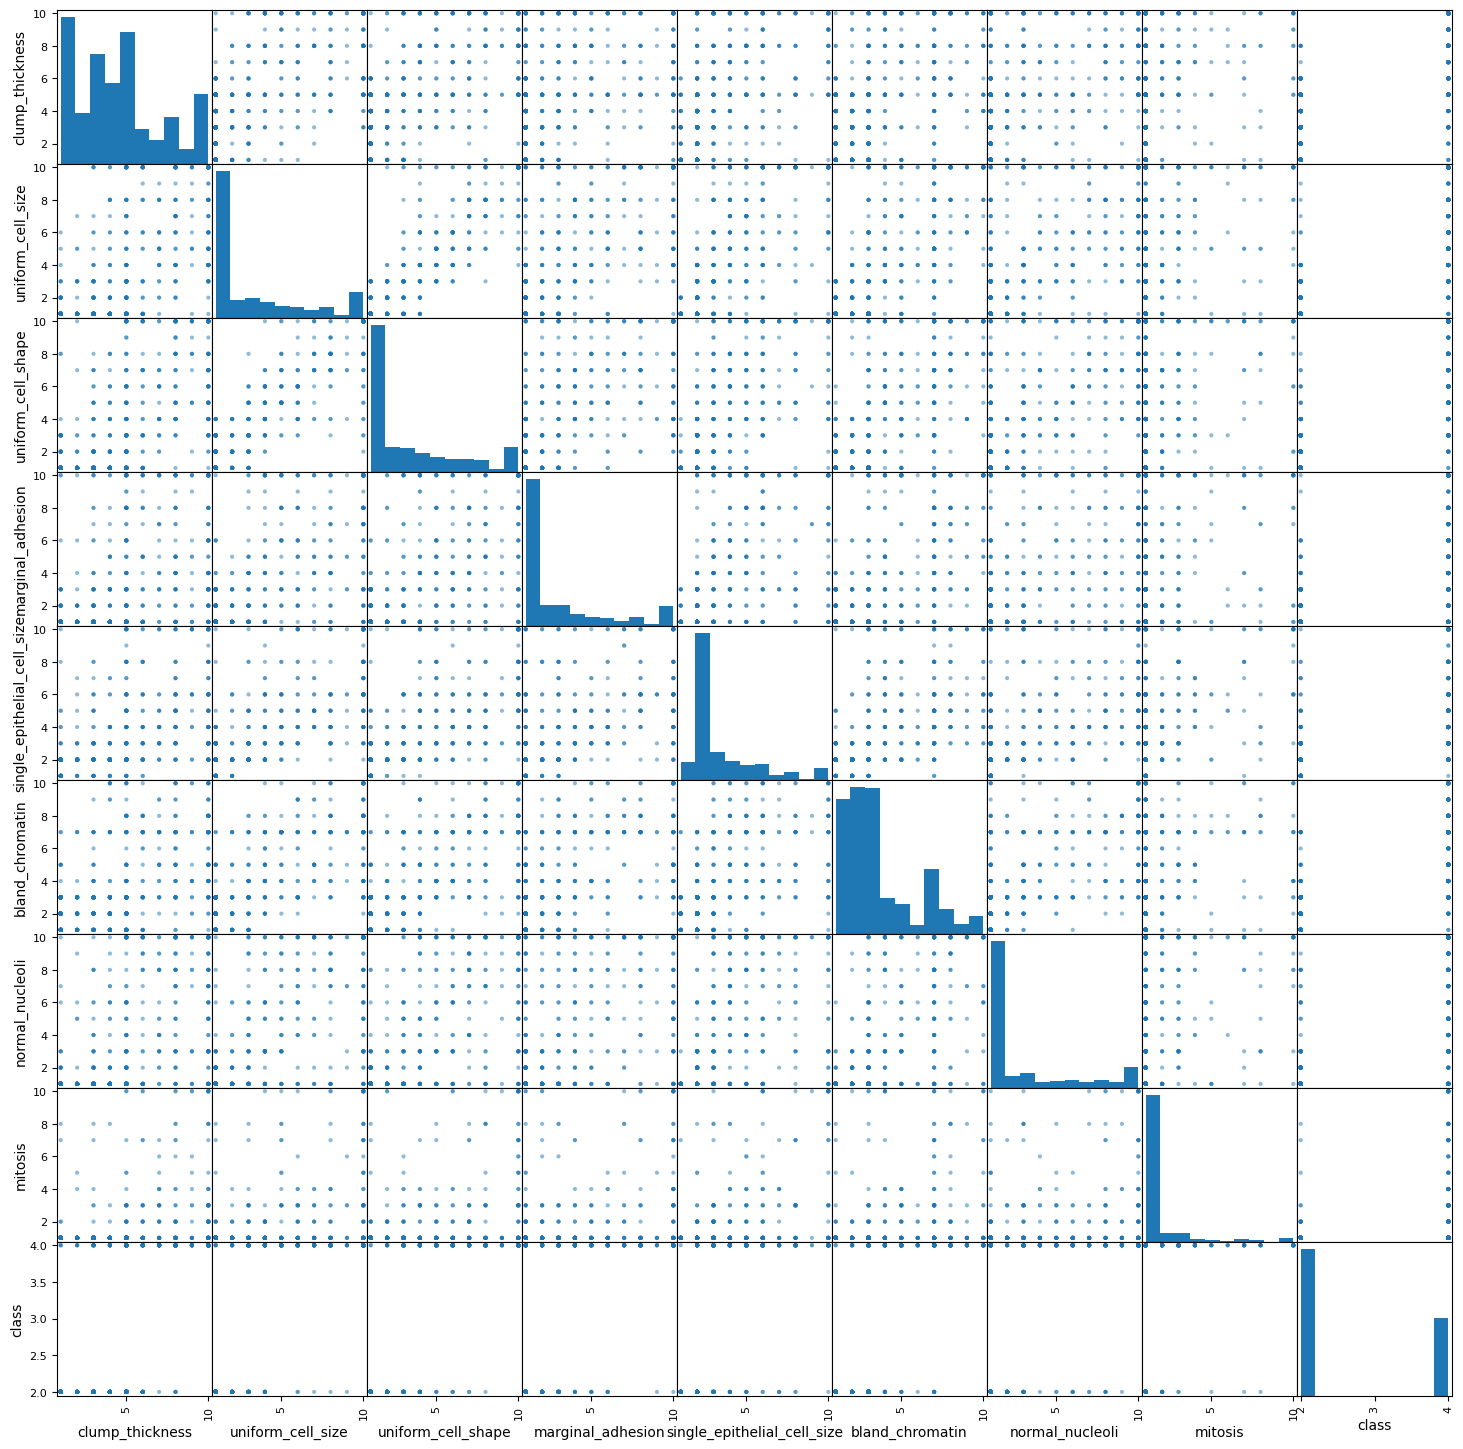

In [28]:
scatter_matrix(df, figsize = (18, 18))
plt.show()

In [29]:
X = np.array(df.drop(columns='class', axis=1))
y = np.array(df['class'])

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2)

seed = 8
scoring = 'accuracy'

In [30]:
models = []
models.append(('KNN', KNeighborsClassifier(n_neighbors = 5)))
models.append(('SVM', SVC(gamma="auto")))

results = []
names = []

for name, model in models:
  kfold = model_selection.KFold(n_splits=10)
  cv_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

KNN: 0.967825 (0.020803)
SVM: 0.960617 (0.029715)


In [36]:
for name, model in models:
  model.fit(X_train, y_train)
  predictions = model.predict(X_test)
  print(f'{name}: {accuracy_score(y_test, predictions)}')
  print(classification_report(y_test, predictions))
  
KNeighborsClassifier()

KNN: 0.9642857142857143
              precision    recall  f1-score   support

           2       0.99      0.96      0.97        91
           4       0.92      0.98      0.95        49

    accuracy                           0.96       140
   macro avg       0.96      0.97      0.96       140
weighted avg       0.97      0.96      0.96       140

SVM: 0.9428571428571428
              precision    recall  f1-score   support

           2       0.99      0.92      0.95        91
           4       0.87      0.98      0.92        49

    accuracy                           0.94       140
   macro avg       0.93      0.95      0.94       140
weighted avg       0.95      0.94      0.94       140



KNeighborsClassifier()

In [38]:
X = np.array(df.drop(['class'], axis=1))
y = np.array(df['class'])

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2)

seed = 8
scoring = 'accuracy'

models = []
models.append(('KNN', KNeighborsClassifier(n_neighbors = 5)))
models.append(('SVM', SVC(gamma="auto")))

results = []
names = []

for name, model in models:
  model.fit(X_train, y_train)
  predictions = model.predict(X_test)
  print(f'{name}: {accuracy_score(y_test, predictions)}')
  print(classification_report(y_test, predictions))
KNeighborsClassifier()


KNN: 0.9785714285714285
              precision    recall  f1-score   support

           2       1.00      0.97      0.98        91
           4       0.94      1.00      0.97        49

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140

SVM: 0.95
              precision    recall  f1-score   support

           2       1.00      0.92      0.96        91
           4       0.88      1.00      0.93        49

    accuracy                           0.95       140
   macro avg       0.94      0.96      0.95       140
weighted avg       0.96      0.95      0.95       140



KNeighborsClassifier()

In [39]:
clf = SVC(gamma="auto")

clf.fit(X_train, y_train)
accuracy = clf.score(X_test, y_test)
print(accuracy)

example_measures = np.array([[4, 2, 1, 1, 1, 2, 3, 2, 1]])
example_measures = example_measures.reshape(len(example_measures), -1)
prediction = clf.predict(example_measures)
print(prediction)
SVC(gamma='auto')

0.95
[2]


SVC(gamma='auto')

In [40]:
print(df.loc[9])

clump_thickness                4
uniform_cell_size              2
uniform_cell_shape             1
marginal_adhesion              1
single_epithelial_cell_size    2
bare_nuclei                    1
bland_chromatin                2
normal_nucleoli                1
mitosis                        1
class                          2
Name: 9, dtype: object
